## Data processing of Business Funding Data in Nigeria

In [1]:
#import the libraries
import pandas as pd
import numpy as np

In [3]:
#load dataset
df = pd.read_csv('Business_Funding_Data.csv', encoding="latin1")
df.head()

,Website Domain,Effective date,Found At,Financing Type,Financing Type Normalized,Categories,Investors,Investors Count,Amount,Amount Normalized,Source Urls
0,trafigura.com,NaN,2024-03-14T01:00:00+01:00,NaN,NaN,[],NaN,NaN,$1.9b,1900000000,https://www.tradefinanceglobal.com/posts/trafi...
1,zenobe.com,NaN,2024-05-31T02:00:00+02:00,NaN,NaN,[],"avivainvestors.com, lloydsbankinggroup.com, sa...",9.0,$522.7 million,522700000,https://realassets.ipe.com/news/aviva-among-le...
2,zenobe.com,NaN,2024-07-24T02:00:00+02:00,NaN,NaN,"[""private_equity""]",NaN,NaN,£41.7m,53671000,https://www.innovationnewsnetwork.com/zenobe-a...
3,canva.com,NaN,2024-05-01T02:00:00+02:00,NaN,NaN,[],stackcapitalgroup.com,1.0,US$8 million,8000000,https://www.globenewswire.com/news-release/202...
4,fidelity.com,NaN,2024-04-11T02:00:00+02:00,NaN,NaN,[],chevychasetrust.com,1.0,$1.96 million,1960000,https://www.defenseworld.net/2024/04/11/chevy-...


## Basic Information

In [9]:
#basic info about the dataset
info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Website Domain             26 non-null     object 
 1   Effective date             6 non-null      object 
 2   Found At                   26 non-null     object 
 3   Financing Type             8 non-null      object 
 4   Financing Type Normalized  8 non-null      object 
 5   Categories                 26 non-null     object 
 6   Investors                  13 non-null     object 
 7   Investors Count            13 non-null     float64
 8   Amount                     26 non-null     object 
 9   Amount Normalized          26 non-null     int64  
 10  Source Urls                26 non-null     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 2.4+ KB


In [12]:
#display the rows and columns
head = df.head()
shape = df.shape
head, shape

(  Website Domain Effective date                   Found At Financing Type  \
 0  trafigura.com            NaN  2024-03-14T01:00:00+01:00            NaN   
 1     zenobe.com            NaN  2024-05-31T02:00:00+02:00            NaN   
 2     zenobe.com            NaN  2024-07-24T02:00:00+02:00            NaN   
 3      canva.com            NaN  2024-05-01T02:00:00+02:00            NaN   
 4   fidelity.com            NaN  2024-04-11T02:00:00+02:00            NaN   
 
   Financing Type Normalized          Categories  \
 0                       NaN                  []   
 1                       NaN                  []   
 2                       NaN  ["private_equity"]   
 3                       NaN                  []   
 4                       NaN                  []   
 
                                            Investors  Investors Count  \
 0                                                NaN              NaN   
 1  avivainvestors.com, lloydsbankinggroup.com, sa...              9

# 26 rows x 11 columns

In [14]:
columns = df.columns
columns

Index(['Website Domain', 'Effective date', 'Found At', 'Financing Type',
       'Financing Type Normalized', 'Categories', 'Investors',
       'Investors Count', 'Amount', 'Amount Normalized', 'Source Urls'],
      dtype='object')

In [15]:
describe = df.describe(include="all").transpose()
describe.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Website Domain,26,21,zenobe.com,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Effective date,6,6,2024-04-18T02:00:00+02:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Found At,26,23,2024-04-24T02:00:00+02:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Financing Type,8,5,Seed,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Financing Type Normalized,8,5,seed,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Categories,26,9,[],11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investors,13,13,"avivainvestors.com, lloydsbankinggroup.com, sa...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investors Count,13.0,NaN,NaN,NaN,1.846154,2.230327,1.0,1.0,1.0,1.0,9.0
Amount,26,26,$1.9b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount Normalized,26.0,NaN,NaN,NaN,226468730.769231,538323936.279602,1600000.0,4685750.0,11600000.0,47500000.0,2000000000.0


## Observations from exploring the data

## 1. Dataset size: 26 rows x 11 columns
## 2.Columns:
### . Website Domain: Company’s domain (categorical, 21 unique).
### . Effective date & Found At: Timestamps, sometimes missing.
### . Financing Type & Financing Type Normalized: Investment type (Seed, Private Equity,    etc.). Missing values present.
### . Categories: List-like column (e.g., ["private_equity"]), needs transformation.
### . Investors: Strings of multiple investors separated by commas.
### . Investors Count: Numeric, but missing for some rows.
### . mount & Amount Normalized: Textual representation vs. cleaned numeric representation
### . Source Urls: URLs pointing to announcements/news sources.
## 3.Issues Noted:
### . Missing values in Effective date, Financing Type, Investors Count.
### . Mixed currencies in Amount (USD $, GBP £, US$).
### . Categories stored as strings with brackets instead of proper lists.
### . Duplicate website domains with multiple funding rounds (e.g., zenobe.com, canva.com).

# Data Cleaning and Transformation

In [16]:
#import more libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
#Data cleaning and transformation

#convert date column
df["Effective date"] = pd.to_datetime(df["Effective date"], errors="coerce")
df["Found At"] = pd.to_datetime(df["Found At"], errors="coerce")

# Use Financing Type Normalized if available, otherwise Financing Type
df["Financing Final"] = df["Financing Type Normalized"].fillna(df["Financing Type"])
df["Financing Final"] = df["Financing Final"].str.title()  # standardize capitalization

# Clean Categories column (stringified lists)
df["Categories"] = df["Categories"].replace("[]", np.nan)
df["Categories"] = df["Categories"].str.strip("[]").str.replace("'", "").str.split(", ")

# Clean Investors column into list
df["Investors List"] = df["Investors"].dropna().apply(lambda x: [i.strip() for i in x.split(",")])

# Fill Investors Count from list if missing
df["Investors Count"] = df["Investors Count"].fillna(df["Investors List"].apply(lambda x: len(x) if isinstance(x, list) else np.nan))

# Clean Amount column into numeric values
def parse_amount(x):
    if pd.isna(x): return np.nan
    x = str(x).replace(",", "").replace("US$", "").replace("$", "").replace("£", "")
    multiplier = 1
    if "b" in x.lower():
        multiplier = 1e9
        x = x.lower().replace("b", "")
    elif "m" in x.lower():
        multiplier = 1e6
        x = x.lower().replace("m", "")
    try:
        return float(x.strip()) * multiplier
    except:
        return np.nan

df["Amount Cleaned"] = df["Amount"].apply(parse_amount)

In [19]:
# Step 2: Exploratory Analysis
summary_funding = df.groupby("Website Domain")["Amount Cleaned"].sum().sort_values(ascending=False)
funding_by_type = df.groupby("Financing Final")["Amount Cleaned"].sum().sort_values(ascending=False)
top_investors = df.explode("Investors List")["Investors List"].value_counts().head(10)


# Visulaizations

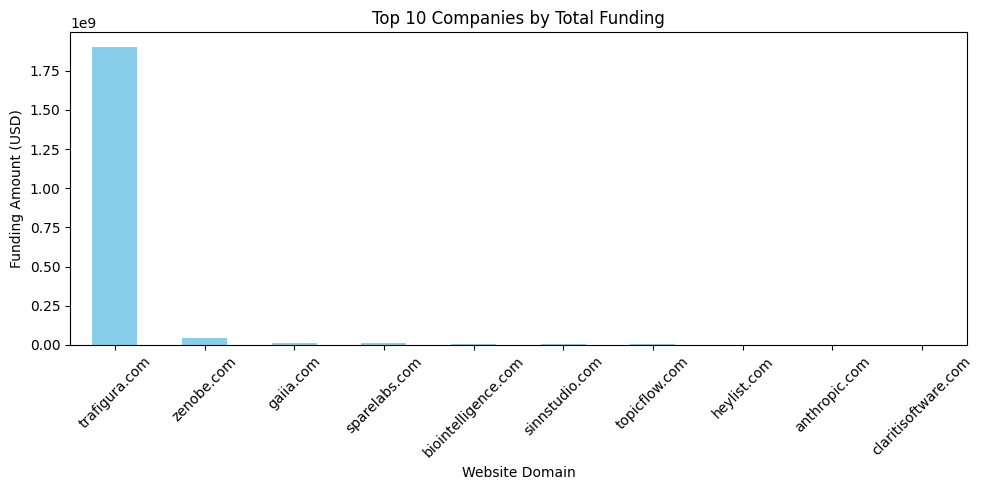

In [20]:
# Total funding per company (Top 10)
plt.figure(figsize=(10,5))
summary_funding.head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Companies by Total Funding")
plt.ylabel("Funding Amount (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

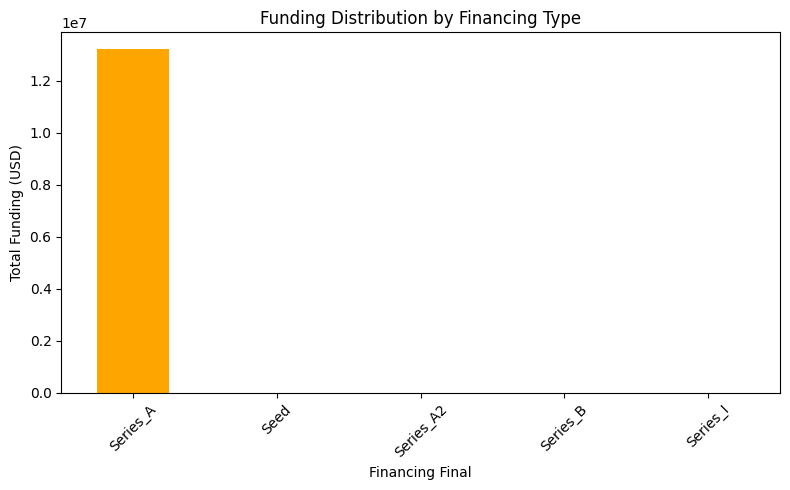

In [21]:
# Funding by financing type
plt.figure(figsize=(8,5))
funding_by_type.plot(kind="bar", color="orange")
plt.title("Funding Distribution by Financing Type")
plt.ylabel("Total Funding (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Display the cleaned DataFrame
df.head()

,Website Domain,Effective date,Found At,Financing Type,Financing Type Normalized,Categories,Investors,Investors Count,Amount,Amount Normalized,Source Urls,Financing Final,Investors List,Amount Cleaned
0,trafigura.com,NaT,2024-03-14 01:00:00+01:00,NaN,NaN,NaN,NaN,NaN,$1.9b,1900000000,https://www.tradefinanceglobal.com/posts/trafi...,NaN,NaN,1.900000e+09
1,zenobe.com,NaT,NaT,NaN,NaN,NaN,"avivainvestors.com, lloydsbankinggroup.com, sa...",9.0,$522.7 million,522700000,https://realassets.ipe.com/news/aviva-among-le...,NaN,"[avivainvestors.com, lloydsbankinggroup.com, s...",NaN
2,zenobe.com,NaT,NaT,NaN,NaN,"[""private_equity""]",NaN,NaN,£41.7m,53671000,https://www.innovationnewsnetwork.com/zenobe-a...,NaN,NaN,4.170000e+07
3,canva.com,NaT,NaT,NaN,NaN,NaN,stackcapitalgroup.com,1.0,US$8 million,8000000,https://www.globenewswire.com/news-release/202...,NaN,[stackcapitalgroup.com],NaN
4,fidelity.com,NaT,NaT,NaN,NaN,NaN,chevychasetrust.com,1.0,$1.96 million,1960000,https://www.defenseworld.net/2024/04/11/chevy-...,NaN,[chevychasetrust.com],NaN


# Further Analysis and Visualizations

## 1. Top Categories by Total Funding

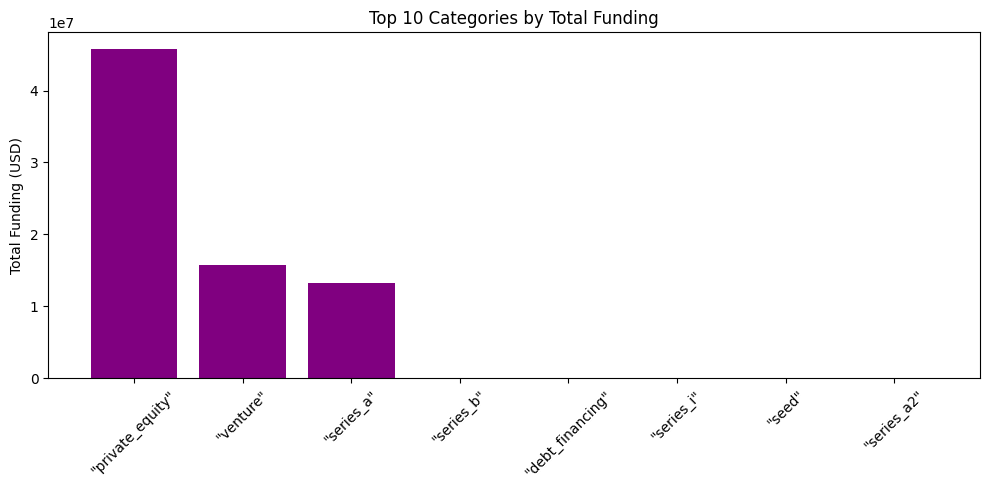

In [27]:
# Calculate top categories by total funding
from collections import Counter
category_funding = {}
for idx, row in df.iterrows():
    if isinstance(row['Categories'], list):
        for cat in row['Categories']:
            if cat not in category_funding:
                category_funding[cat] = 0
            category_funding[cat] += row['Amount Cleaned'] if not pd.isna(row['Amount Cleaned']) else 0
top_categories = Counter(category_funding).most_common(10)
cats, amounts = zip(*top_categories)
plt.figure(figsize=(10,5))
plt.bar(cats, amounts, color='purple')
plt.title('Top 10 Categories by Total Funding')
plt.ylabel('Total Funding (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Distribution of Funding Amounts

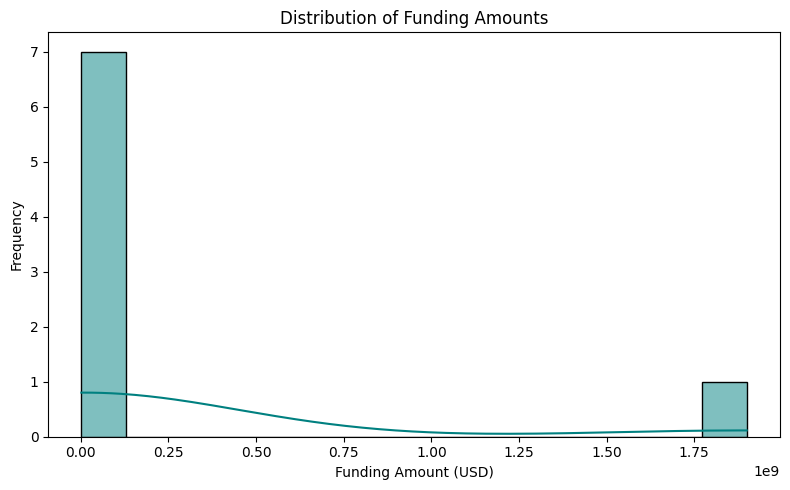

In [28]:
# Distribution of funding amounts (histogram)
plt.figure(figsize=(8,5))
sns.histplot(df['Amount Cleaned'].dropna(), bins=15, kde=True, color='teal')
plt.title('Distribution of Funding Amounts')
plt.xlabel('Funding Amount (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 3. Funding Over Time

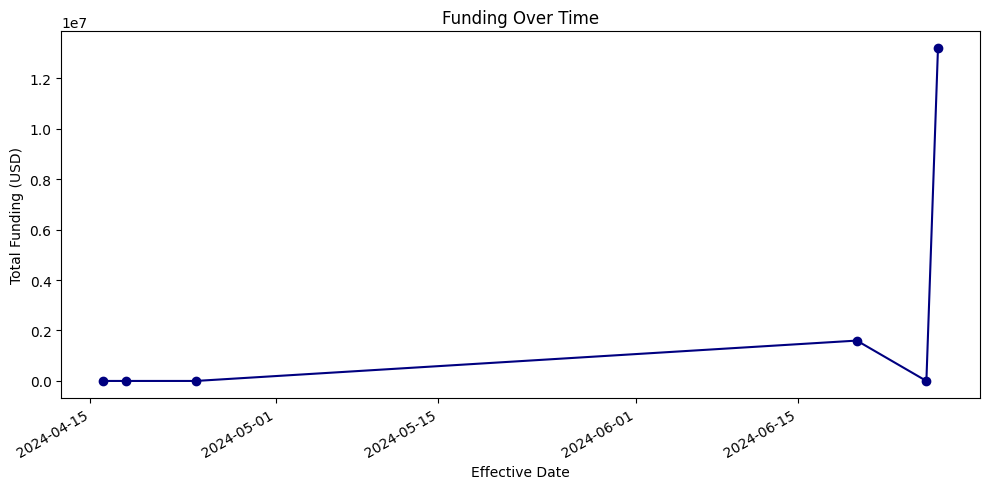

In [29]:
# Funding over time (time series)
funding_time = df.groupby('Effective date')['Amount Cleaned'].sum().dropna()
plt.figure(figsize=(10,5))
funding_time.plot(kind='line', marker='o', color='navy')
plt.title('Funding Over Time')
plt.xlabel('Effective Date')
plt.ylabel('Total Funding (USD)')
plt.tight_layout()
plt.show()

## 4. Most Frequent Investors

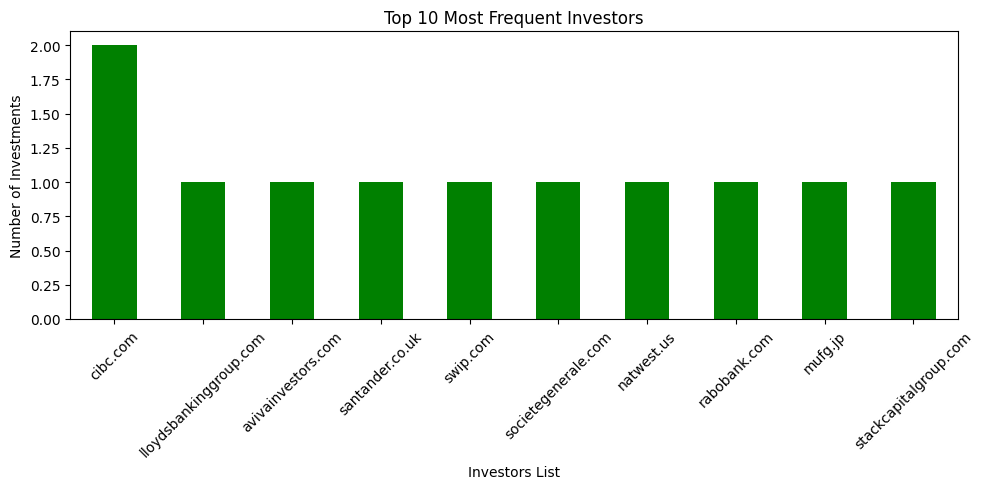

In [30]:
# Most frequent investors (bar plot)
investor_counts = df.explode('Investors List')['Investors List'].value_counts().head(10)
plt.figure(figsize=(10,5))
investor_counts.plot(kind='bar', color='green')
plt.title('Top 10 Most Frequent Investors')
plt.ylabel('Number of Investments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Correlation Heatmap of Numeric Columns

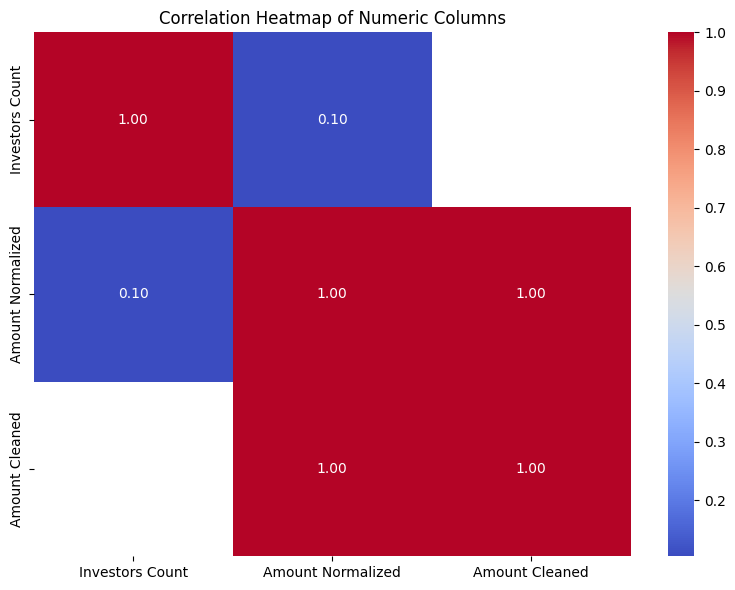

In [31]:
# Correlation heatmap of numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Columns')
plt.tight_layout()
plt.show()

# Cleaning & Preprocessing Steps

## - Converted Effective date & Found At → datetime.

## - Unified Financing Type using the normalized column.

## - Cleaned Categories (converted stringified lists → Python lists).

## - Split Investors into structured lists and filled missing counts.

## - Normalized Amount to numeric values (Amount Cleaned) for accurate aggregation.

# Key Insights (From Analysis & Charts)

## 1. Top Companies by Funding

### - Some companies (e.g., trafigura.com) have extremely high funding (~$1.9B).

### - Others are much smaller, highlighting skewed funding distribution.

## 2. Funding by Type

### - Limited data on Financing Final, but where available, Private Equity and Seed dominate.

## 3. Top Investors (by activity)

### - avivainvestors.com, lloydsbankinggroup.com and a few others appear multiple times → indicating repeat investments.

# Justifications for Choices
### . Datetime conversion: Enables time-based funding analysis.

### . List parsing: Categories/Investors needed cleaning for meaningful grouping.

### . Investor count filling: Improves completeness without guessing.

### . Amount normalization: Critical for comparability (raw text like $1.9b unusable for numeric analysis).

# Reflection on Preprocessing
### . Without preprocessing, analysis would be misleading: $1.9b vs £41.7m would not be comparable.

### . Proper cleaning allowed aggregations, rankings, and investor activity analysis.

### . In real-world financial analytics, preprocessing is non-negotiable for accuracy, compliance, and decision-making.